---
# Building Traditional RAG Using ChromaDB Vector Store

---

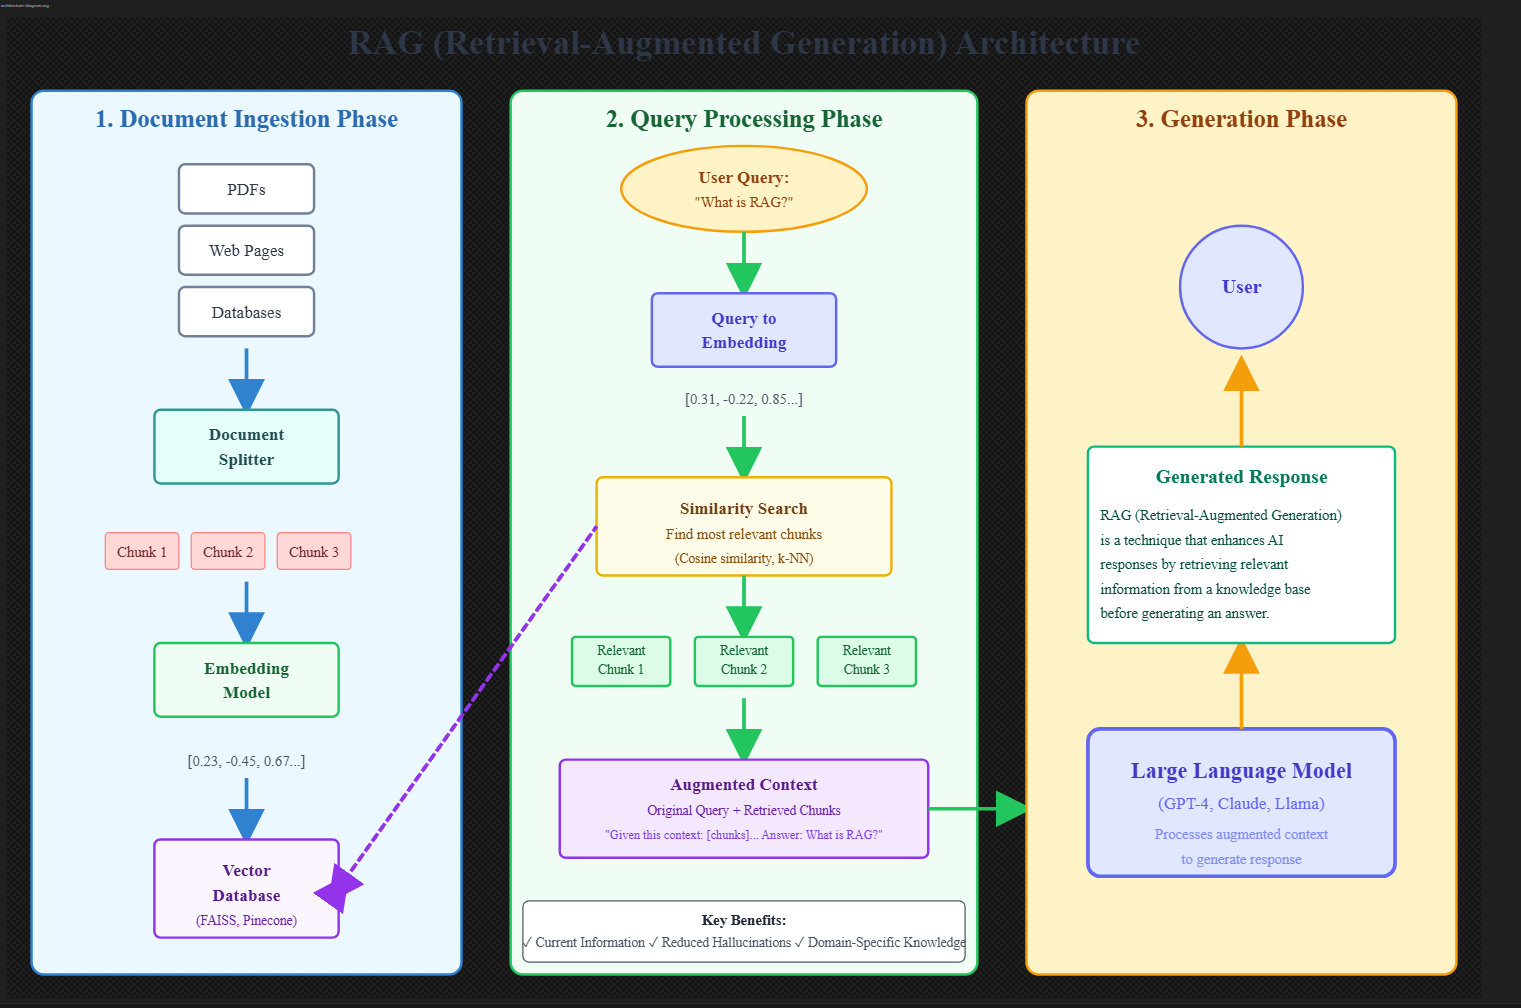

---

## Building a RAG System with LangChain and ChromaDB
### Introduction
`Retrieval-Augmented Generation (RAG)` is a powerful technique that combines the capabilities of large language models with external knowledge retrieval. This notebook will walk you through building a complete RAG system using:

- **LangChain**: A framework for developing applications powered by language models
- **ChromaDB**: An open-source vector database for storing and retrieving embeddings
- **OpenAI**: For embeddings and language model (you can substitute with other providers)

### ChromaDB 👉 [Learn more](https://www.trychroma.com/)
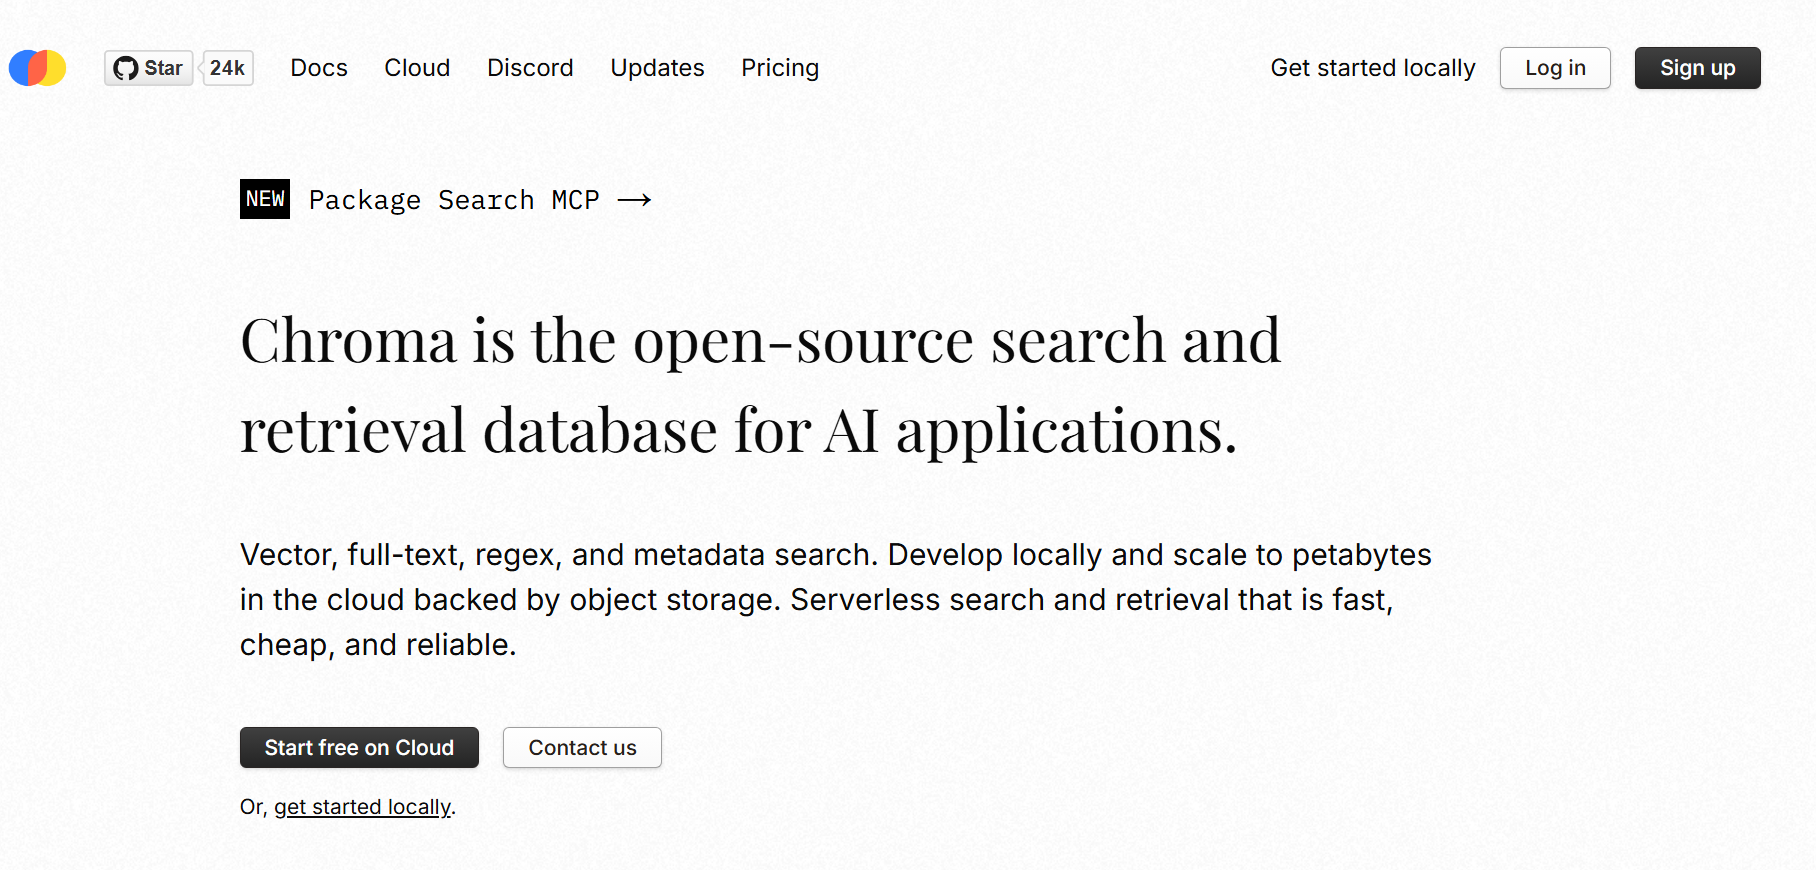 <br><br>
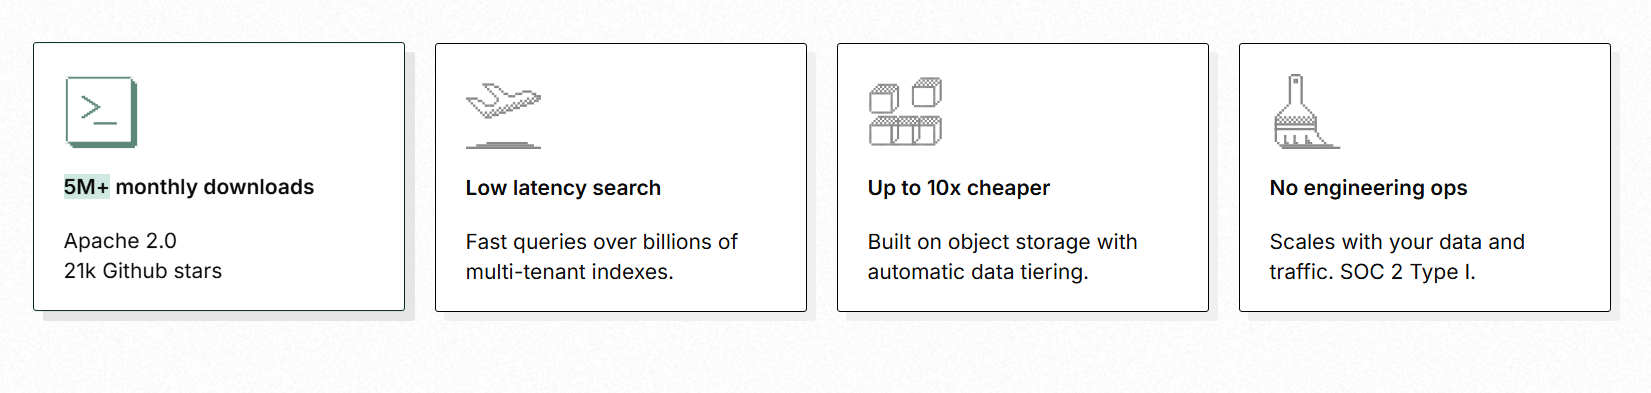 <br><br>
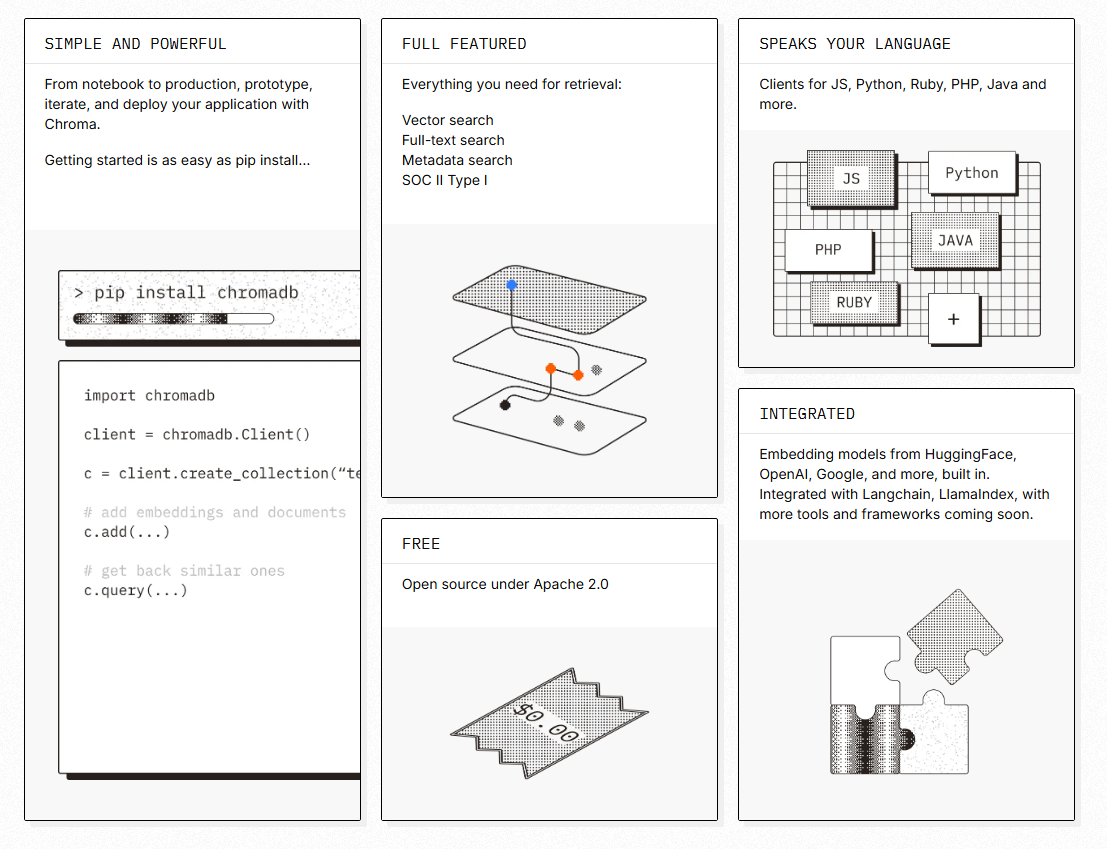

----

#### Load `.env` file

In [10]:
# Load dotenv file
import os 
from dotenv import load_dotenv
load_dotenv()

True

----

#### Langchain Libraries

In [11]:
# Langchain imports
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain.schema import Document
from langchain_core.documents import Document

# Vectorstores
from langchain_community.vectorstores import Chroma

# Utility imports
import numpy as np
from typing import List 

---

#### RAG Architecture Overview

In [12]:
# RAG Architecture Overview
print("""
RAG (Retrieval-Augmented Generation) Architecture:

1. Document Loading: Load documents from various sources
2. Document Splitting: Break documents into smaller chunks
3. Embedding Generation: Convert chunks into vector representations
4. Vector Storage: Store embeddings in ChromaDB
5. Query Processing: Convert user query to embedding
6. Similarity Search: Find relevant chunks from vector store
7. Context Augmentation: Combine retrieved chunks with query
8. Response Generation: LLM generates answer using context

Benefits of RAG:
- Reduces hallucinations
- Provides up-to-date information
- Allows citing sources
- Works with domain-specific knowledge
""")


RAG (Retrieval-Augmented Generation) Architecture:

1. Document Loading: Load documents from various sources
2. Document Splitting: Break documents into smaller chunks
3. Embedding Generation: Convert chunks into vector representations
4. Vector Storage: Store embeddings in ChromaDB
5. Query Processing: Convert user query to embedding
6. Similarity Search: Find relevant chunks from vector store
7. Context Augmentation: Combine retrieved chunks with query
8. Response Generation: LLM generates answer using context

Benefits of RAG:
- Reduces hallucinations
- Provides up-to-date information
- Allows citing sources
- Works with domain-specific knowledge



---

#### 1. Sample Data

In [13]:
# Create sample documents
sample_docs = [
    """
    Machine Learning Fundamentals
    
    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are three main 
    types of machine learning: supervised learning, unsupervised learning, and reinforcement 
    learning. Supervised learning uses labeled data to train models, while unsupervised 
    learning finds patterns in unlabeled data. Reinforcement learning learns through 
    interaction with an environment using rewards and penalties.
    """,
    
    """
    Deep Learning and Neural Networks
    
    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of interconnected 
    nodes. Deep learning has revolutionized fields like computer vision, natural language 
    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly 
    effective for image processing, while Recurrent Neural Networks (RNNs) and Transformers 
    excel at sequential data processing.
    """,
    
    """
    Natural Language Processing (NLP)
    
    NLP is a field of AI that focuses on the interaction between computers and human language. 
    Key tasks in NLP include text classification, named entity recognition, sentiment analysis, 
    machine translation, and question answering. Modern NLP heavily relies on transformer 
    architectures like BERT, GPT, and T5. These models use attention mechanisms to understand 
    context and relationships between words in text.
    """
]

sample_docs


['\n    Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through \n    interaction with an environment using rewards and penalties.\n    ',
 '\n    Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like computer vision, natural language \n    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly \n    effective f

In [14]:
len(sample_docs)

3

`tempfile.mkdtemp()` in Python is a function that creates a temporary directory and returns the path to it as a string.

In [15]:
# Save Sample file documents to files
import tempfile

temp_dir = tempfile.mkdtemp()

for i,doc in enumerate(sample_docs):
    with open(f"{temp_dir}/doc_{i}.txt", "w") as f:
        f.write(doc)

print(f"Sample document create in : {temp_dir}")

Sample document create in : C:\Users\Satish\AppData\Local\Temp\tmpg_ok6w4g


In [16]:
temp_dir

'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g'

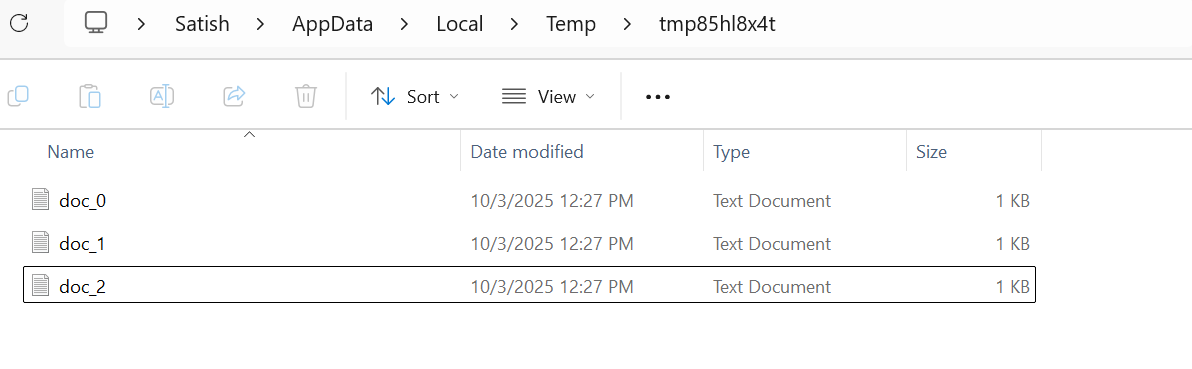 <br><br> 
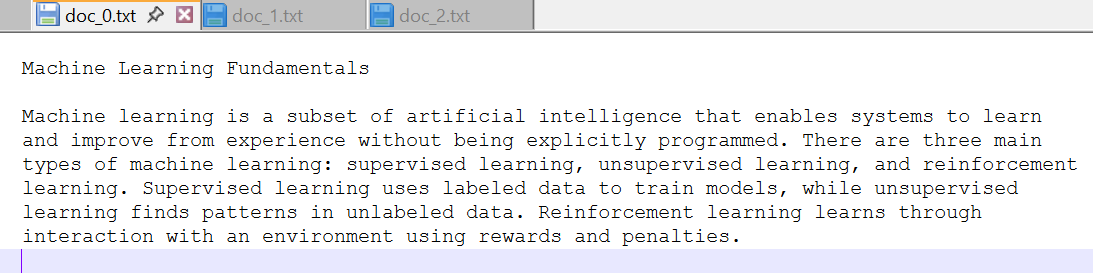 <br><br>
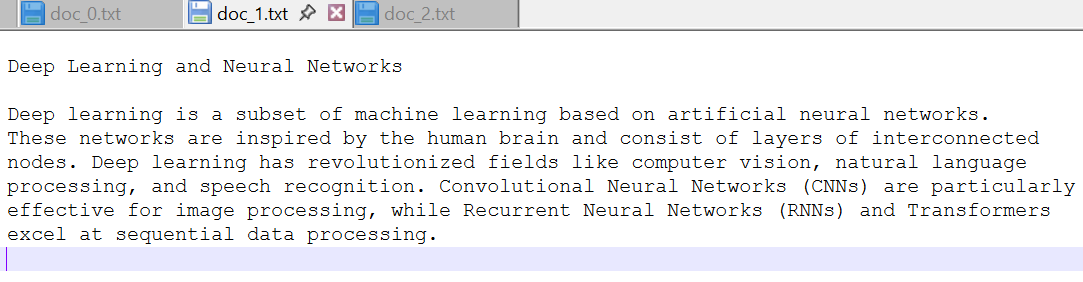 <br><br>
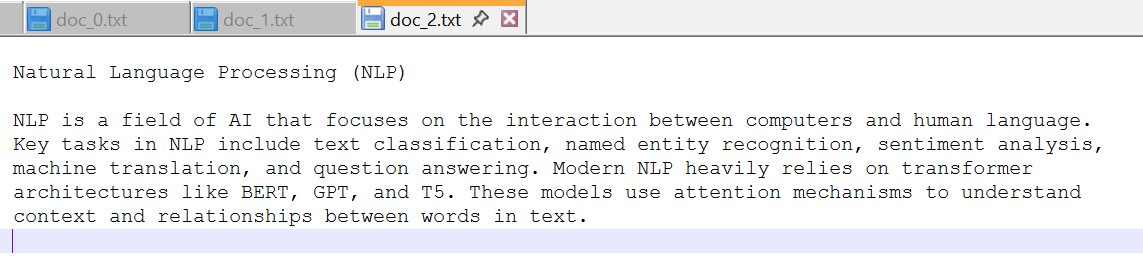 <br><br>

In [17]:
import os
os.makedirs("data", exist_ok=True)

for i,doc in enumerate(sample_docs):
    with open(f"data/doc_{i}.txt", "w") as f:
        f.write(doc)

print(f"Sample document create")

Sample document create


---

#### 2. Document Loading

In [18]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# Load dcouments from directory
loader = DirectoryLoader(
    temp_dir,
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={'encoding': 'utf-8'}
)
documents = loader.load()

print(f"Loaded {len(documents)} documents")
print(f"\nFirst document preview:")
print(documents[0].page_content[:200] + ".....")
print(f"\nSecond document preview:")
print(documents[1].page_content[:200] + ".....")
print(f"\nThird document preview:")
print(documents[2].page_content[:200] + ".....")


Loaded 3 documents

First document preview:

    Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. Ther.....

Second document preview:

    Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers.....

Third document preview:

    Natural Language Processing (NLP)

    NLP is a field of AI that focuses on the interaction between computers and human language. 
    Key tasks in NLP include text classification, named entity r.....


In [19]:
documents

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='\n    Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through \n    interaction with an environment using rewards and penalties.\n    '),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='\n    Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of

---

#### 3. Document Splitting

In [20]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Initialize text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, # Maximum size of each chunk
    chunk_overlap=50, # Overlap between chunks to maintain context
    length_function=len,
    separators=[" "] # Hierarchy of separators
)
chunks = text_splitter.split_documents(documents)

print(f"Created {len(chunks)} chunks from {len(documents)} documents")
print(f"\nChunk example:")
print(f"Content: {chunks[0].page_content[:150]}.....")
print(f"Metadata: {chunks[0].metadata}")

Created 5 chunks from 3 documents

Chunk example:
Content: Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experie.....
Metadata: {'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}


In [21]:
chunks

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='data. Reinforcement learning learns through \n    interaction with an environment using rewards and penalties.'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a 

---

#### 4. Embeddings Models

In [22]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [23]:
from langchain_openai import OpenAIEmbeddings

sample_text = "Machine Learning is fascinating"
embeddings = OpenAIEmbeddings()
embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000001F96D830C20>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000001F96D831550>, model='text-embedding-ada-002', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [24]:
vector = embeddings.embed_query(sample_text)
vector

[-0.02172444760799408,
 0.016208980232477188,
 0.010213345289230347,
 -0.022516079246997833,
 -0.0037213172763586044,
 0.01783117651939392,
 4.82096329506021e-05,
 0.01027174387127161,
 -0.015547124668955803,
 -0.04134652763605118,
 0.007929293438792229,
 0.03628527745604515,
 -0.019128933548927307,
 -0.008234266191720963,
 -0.0013058676850050688,
 0.00581719446927309,
 0.03880292549729347,
 0.008811768144369125,
 -0.0005584409227594733,
 -0.008591149002313614,
 -0.031224025413393974,
 0.022048886865377426,
 -0.005914526060223579,
 -0.03441650792956352,
 -0.014898247085511684,
 0.0023018959909677505,
 0.003834871109575033,
 -0.03885483369231224,
 -0.012523352168500423,
 -0.002739888848736882,
 0.027590306475758553,
 -0.004736811853945255,
 -0.0170655008405447,
 -0.03981517627835274,
 -0.008513283915817738,
 -0.012211889959871769,
 -0.004152821376919746,
 0.0028583090752363205,
 -0.01670212857425213,
 -0.00013068816042505205,
 0.020076295360922813,
 0.02541007660329342,
 -0.008435418829

---

#### Intilialize the `ChromaDB` Vector Store And Stores the chunks in Vector Representation

In [25]:
chunks

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='data. Reinforcement learning learns through \n    interaction with an environment using rewards and penalties.'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a 

In [26]:
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

# Create a Chromadb Vector Store
persist_directory="./chroma_db"

# Initialize ChromaDB with OpenAI Embeddings
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=OpenAIEmbeddings(),
    persist_directory=persist_directory,
    collection_name="rag_collection"
)

print(f"Vector store created with {vectorstore._collection.count()}")
print(f"Persisted to: {persist_directory}")


Vector store created with 10
Persisted to: ./chroma_db


---

##### **Test Similarity Search**

In [27]:
query = "What are the types of machine learning"

similar_docs = vectorstore.similarity_search(query, k=3)
similar_docs

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpcc1k4neo\\doc_0.txt'}, page_content='Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised lear

In [28]:
print(f"Query: {query}")
print(f"\nTop {len(similar_docs)} similar chunks:")

for i, doc in enumerate(similar_docs):
    print(f"\n--- Chunk {i+1} --")
    print(doc.page_content[:200] + ".....")
    print(f"Source: {doc.metadata.get('source', 'Unknown')}")

Query: What are the types of machine learning

Top 3 similar chunks:

--- Chunk 1 --
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpcc1k4neo\doc_0.txt

--- Chunk 2 --
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpg_ok6w4g\doc_0.txt

--- Chunk 3 --
Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of i.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpcc1k4neo\doc_1.txt


In [29]:
query="what is NLP?"

similar_docs = vectorstore.similarity_search(query,k=3)
similar_docs

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpcc1k4neo\\doc_2.txt'}, page_content='Natural Language Processing (NLP)\n\n    NLP is a field of AI that focuses on the interaction between computers and human language. \n    Key tasks in NLP include text classification, named entity recognition, sentiment analysis, \n    machine translation, and question answering. Modern NLP heavily relies on transformer \n    architectures like BERT, GPT, and T5. These models use attention mechanisms to understand \n    context and relationships between words in text.'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_2.txt'}, page_content='Natural Language Processing (NLP)\n\n    NLP is a field of AI that focuses on the interaction between computers and human language. \n    Key tasks in NLP include text classification, named entity recognition, sentiment analysis, \n    machine translation, and question answering. Modern NLP heavily 

In [30]:
print(f"Query: {query}")
print(f"\nTop {len(similar_docs)} similar chunks:")

for i, doc in enumerate(similar_docs):
    print(f"\n--- Chunk {i+1} --")
    print(doc.page_content[:200] + ".....")
    print(f"Source: {doc.metadata.get('source', 'Unknown')}")

Query: what is NLP?

Top 3 similar chunks:

--- Chunk 1 --
Natural Language Processing (NLP)

    NLP is a field of AI that focuses on the interaction between computers and human language. 
    Key tasks in NLP include text classification, named entity recogn.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpcc1k4neo\doc_2.txt

--- Chunk 2 --
Natural Language Processing (NLP)

    NLP is a field of AI that focuses on the interaction between computers and human language. 
    Key tasks in NLP include text classification, named entity recogn.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpg_ok6w4g\doc_2.txt

--- Chunk 3 --
Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of i.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpcc1k4neo\doc_1.txt


In [31]:
query="what is Deep Learning?"

similar_docs = vectorstore.similarity_search(query,k=3)
similar_docs

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpcc1k4neo\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like computer vision, natural language \n    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly \n    effective for image processing, while Recurrent Neural Networks (RNNs) and Transformers'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like

In [32]:
print(f"Query: {query}")
print(f"\nTop {len(similar_docs)} similar chunks:")

for i, doc in enumerate(similar_docs):
    print(f"\n--- Chunk {i+1} --")
    print(doc.page_content[:200] + ".....")
    print(f"Source: {doc.metadata.get('source', 'Unknown')}")

Query: what is Deep Learning?

Top 3 similar chunks:

--- Chunk 1 --
Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of i.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpcc1k4neo\doc_1.txt

--- Chunk 2 --
Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of i.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpg_ok6w4g\doc_1.txt

--- Chunk 3 --
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are.....
Source: C:\Users\Satish\AppData\Local\Temp\tmpcc1k4neo\doc_0.txt


---

### Advanced Similarity Search With Scores

In [33]:
results_scores = vectorstore.similarity_search_with_score(query, k=3)
results_scores

[(Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpcc1k4neo\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like computer vision, natural language \n    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly \n    effective for image processing, while Recurrent Neural Networks (RNNs) and Transformers'),
  0.2383197844028473),
 (Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has r

---

#### Understanding Similarity Scores
The similarity score represents how closely related a document chunk is to your query. The scoring depends on the distance metric used:

ChromaDB default: Uses L2 distance (Euclidean distance)

- Lower scores = MORE similar (closer in vector space)
- Score of 0 = identical vectors
- Typical range: 0 to 2 (but can be higher)


Cosine similarity (if configured):

- Higher scores = MORE similar
- Range: -1 to 1 (1 being identical)

---

#### Initialize LLM, RAG Chain, Prompt Template, Query the RAG system

In [34]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-3.5-turbo"
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001F9708D4980>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001F9708D4D70>, root_client=<openai.OpenAI object at 0x000001F97088F610>, root_async_client=<openai.AsyncOpenAI object at 0x000001F97088FC50>, model_kwargs={}, openai_api_key=SecretStr('**********'))

In [35]:
test_response = llm.invoke("What is the RAG?")
test_response

AIMessage(content='RAG stands for Red, Amber, Green. It is a color-coded system used to quickly convey the status or progress of a project, task, or situation. The colors correspond to different levels of urgency or completion:\n\n- Red typically indicates that there are critical issues or delays that need immediate attention.\n- Amber signifies that there are concerns or potential problems that may impact the project or task if not addressed.\n- Green indicates that everything is on track and progressing as expected.\n\nThe RAG rating system is commonly used in project management, risk assessment, and reporting to quickly communicate the status of various items.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 120, 'prompt_tokens': 13, 'total_tokens': 133, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'c

In [36]:
test_response.content

'RAG stands for Red, Amber, Green. It is a color-coded system used to quickly convey the status or progress of a project, task, or situation. The colors correspond to different levels of urgency or completion:\n\n- Red typically indicates that there are critical issues or delays that need immediate attention.\n- Amber signifies that there are concerns or potential problems that may impact the project or task if not addressed.\n- Green indicates that everything is on track and progressing as expected.\n\nThe RAG rating system is commonly used in project management, risk assessment, and reporting to quickly communicate the status of various items.'

In [37]:
from langchain.chat_models.base import init_chat_model

llm = init_chat_model("openai:gpt-3.5-turbo")
# llm = init_chat_model("groq:")
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001F97088EC10>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001F97088C2D0>, root_client=<openai.OpenAI object at 0x000001F9708629E0>, root_async_client=<openai.AsyncOpenAI object at 0x000001F970863490>, model_kwargs={}, openai_api_key=SecretStr('**********'))

In [38]:
response = llm.invoke("What is Agentic AI")
response 

AIMessage(content='Agentic AI describes artificial intelligence that is designed to act autonomously and make decisions without human intervention. This type of AI is often used in applications such as autonomous vehicles, drones, and robots, where the AI system needs to navigate and react to its environment in real-time. Agentic AI is characterized by its ability to perceive, learn, and act in a way that mimics human decision-making processes.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 12, 'total_tokens': 93, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CQYwACOjMz12mK5nVgKv8m0fofjG0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--18bc9baf-dd73

In [39]:
response.content

'Agentic AI describes artificial intelligence that is designed to act autonomously and make decisions without human intervention. This type of AI is often used in applications such as autonomous vehicles, drones, and robots, where the AI system needs to navigate and react to its environment in real-time. Agentic AI is characterized by its ability to perceive, learn, and act in a way that mimics human decision-making processes.'

---

### Modern RAG Chain

In [40]:
from langchain.chains import create_retrieval_chain
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain

In [41]:
# Convert vector store to retriever
retriever = vectorstore.as_retriever(
    search_kwarg={
        "k": 3 # Retrieve Top 3 Relevant Chunks
    }
)

retriever

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001F96D832660>, search_kwargs={})

In [42]:
from langchain_core.prompts import ChatPromptTemplate

# Create a prompt teamplate
system_prompt="""You are an assistant for question-answering tasks. 
Use the following pieces of retrieved context to answer the question. 
If you don't know the answer, just say that you don't know. 
Use three sentences maximum and keep the answer concise.

Context: {context}"""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}")
    ]
)


In [43]:
prompt

ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. \nUse the following pieces of retrieved context to answer the question. \nIf you don't know the answer, just say that you don't know. \nUse three sentences maximum and keep the answer concise.\n\nContext: {context}"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})])

##### What is `create_stuff_documents_chain`?
**create_stuff_documents_chain** creates a chain that "**stuffs**" (inserts) all retrieved documents into a single prompt and sends it to the LLM. It's called "**stuff**" because it literally `stuffs` all the documents into the context window at once.

In [44]:
from langchain.chains.combine_documents import create_stuff_documents_chain

# Create a document chain
document_chain = create_stuff_documents_chain(llm, prompt)

document_chain

RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableLambda(format_docs)
}), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
| ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. \nUse the following pieces of retrieved context to answer the question. \nIf you don't know the answer, just say that you don't know. \nUse three sentences maximum and keep the answer concise.\n\nContext: {context}"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})])
| ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001F97088EC10>, async_client=<openai.res

This chain:

- Takes retrieved documents
- "Stuffs" them into the prompt's {context} placeholder
- Sends the complete prompt to the LLM
- Returns the LLM's response

##### What is `create_retrieval_chain`?
**create_retrieval_chain** is a function that combines a retriever (which fetches relevant documents) with a document chain (which processes those documents with an LLM) to create a complete `RAG` pipeline.

In [45]:
from langchain.chains import create_retrieval_chain

# Create The Final RAG Chain
rag_chain = create_retrieval_chain(retriever, document_chain)

rag_chain

RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableBinding(bound=RunnableLambda(lambda x: x['input'])
           | VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001F96D832660>, search_kwargs={}), kwargs={}, config={'run_name': 'retrieve_documents'}, config_factories=[])
})
| RunnableAssign(mapper={
    answer: RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
              context: RunnableLambda(format_docs)
            }), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
            | ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. \nUse the following pieces of retrieved context to answer the question. \nIf you don'

In [46]:
response = rag_chain.invoke({
    "input": "What is Deep Learning"
})

response

{'input': 'What is Deep Learning',
 'context': [Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpcc1k4neo\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like computer vision, natural language \n    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly \n    effective for image processing, while Recurrent Neural Networks (RNNs) and Transformers'),
  Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nod

In [47]:
response["answer"]

'Deep learning is a subset of machine learning that is based on artificial neural networks. These networks are inspired by the human brain and consist of interconnected layers of nodes. Deep learning has significantly impacted fields such as computer vision, natural language processing, and speech recognition.'

In [48]:
# Function to query the modern RAG System
def query_rag_modern(question):
    print(f"Question: {question}")
    print("-" * 50)

    # Using create_retrieval_chain approach
    result = rag_chain.invoke({"input": question})

    print(f"Answer: {result['answer']}")
    print("\nRetrieved Context:")

    for i,doc in enumerate(result['context']):
        print(f"\n--- Source {i+1} ---")
        print(doc.page_content[:200] + ".....")

    return result

# Test queries
test_questions = [
    "What are the three types of machine learning?",
    "What is deep learning and how does it relate to neural networks?",
    "What are CNNs best used for?"
]

for question in test_questions:
    result = query_rag_modern(question)
    print("\n" + "="*80 + "\n")


Question: What are the three types of machine learning?
--------------------------------------------------
Answer: The three main types of machine learning are supervised learning, unsupervised learning, and reinforcement learning. Supervised learning uses labeled data for training, while unsupervised learning finds patterns in unlabeled data. Reinforcement learning learns through a system of rewards and punishments based on actions.

Retrieved Context:

--- Source 1 ---
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are.....

--- Source 2 ---
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are.....

--- Source 3 ---
Deep Learning and Neural Networks

    Deep learning is a subset of machine 

----

### Create RAG Chain Alternative - Using LCEL (LangChain Expression Language)

In [53]:
# Even more flexible apporach using LCEL

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

In [50]:
# Create a custom prompt
from langchain_core.prompts import ChatPromptTemplate

custom_prompt = ChatPromptTemplate.from_template("""Use the following context to answer the question. 
If you don't know the answer based on the context, say you don't know.
Provide specific details from the context to support your answer.

Context:
{context}

Question: {question}

Answer:""")

custom_prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="Use the following context to answer the question. \nIf you don't know the answer based on the context, say you don't know.\nProvide specific details from the context to support your answer.\n\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"), additional_kwargs={})])

In [51]:
retriever

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001F96D832660>, search_kwargs={})

In [52]:
# Format the output documents for the prompt

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [59]:
from langchain_core.output_parsers import StrOutputParser

# Build the chain using LCEL

rag_chain_lcel = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | custom_prompt
    | llm
    | StrOutputParser()
)

rag_chain_lcel

{
  context: VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001F96D832660>, search_kwargs={})
           | RunnableLambda(format_docs),
  question: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="Use the following context to answer the question. \nIf you don't know the answer based on the context, say you don't know.\nProvide specific details from the context to support your answer.\n\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"), additional_kwargs={})])
| ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001F97088EC10>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001F97088C2D0>, r

In [60]:
response = rag_chain_lcel.invoke("What is Deep Learning")

In [61]:
response

'Deep learning is a subset of machine learning based on artificial neural networks. It involves interconnected layers of nodes inspired by the human brain and has revolutionized fields such as computer vision, natural language processing, and speech recognition.'

In [62]:
retriever.get_relevant_documents("What is Deep Learning")

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpcc1k4neo\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like computer vision, natural language \n    processing, and speech recognition. Convolutional Neural Networks (CNNs) are particularly \n    effective for image processing, while Recurrent Neural Networks (RNNs) and Transformers'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a subset of machine learning based on artificial neural networks. \n    These networks are inspired by the human brain and consist of layers of interconnected \n    nodes. Deep learning has revolutionized fields like

In [63]:
# Query using the LCEL approach - Fixed version

def query_rag_lcel(question):
    print(f"Question: {question}")
    print("-" * 50)
    
    # Method 1: Pass string directly (when using RunnablePassthrough)
    answer = rag_chain_lcel.invoke(question)
    print(f"Answer: {answer}")
    
    # Get source documents separately if needed
    docs = retriever.get_relevant_documents(question)
    print("\nSource Documents:")
    for i, doc in enumerate(docs):
        print(f"\n--- Source {i+1} ---")
        print(doc.page_content[:200] + "...")
        

In [64]:
# Test LCEL Chain

print("Testing LCEL Chain:")
query_rag_lcel("What are the key concepts in reinforcement learning?")

Testing LCEL Chain:
Question: What are the key concepts in reinforcement learning?
--------------------------------------------------
Answer: The key concepts in reinforcement learning are interaction with an environment using rewards and penalties.

Source Documents:

--- Source 1 ---
data. Reinforcement learning learns through 
    interaction with an environment using rewards and penalties....

--- Source 2 ---
data. Reinforcement learning learns through 
    interaction with an environment using rewards and penalties....

--- Source 3 ---
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are...

--- Source 4 ---
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and improve from experience without being explicitly programmed. There are...


In [65]:
query_rag_lcel("WHat is deep learning?")

Question: WHat is deep learning?
--------------------------------------------------
Answer: Deep learning is a subset of machine learning based on artificial neural networks. These networks are inspired by the human brain and consist of layers of interconnected nodes. Deep learning has revolutionized fields like computer vision, natural language processing, and speech recognition.

Source Documents:

--- Source 1 ---
Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of i...

--- Source 2 ---
Deep Learning and Neural Networks

    Deep learning is a subset of machine learning based on artificial neural networks. 
    These networks are inspired by the human brain and consist of layers of i...

--- Source 3 ---
Machine Learning Fundamentals

    Machine learning is a subset of artificial intelligence that enables systems to learn 
    and impro

---

### Add New Documents To Existing Vector Store

In [66]:
vectorstore

In [67]:
# Add new documents to the existing vector store
new_document = """
Reinforcement Learning in Detail

Reinforcement learning (RL) is a type of machine learning where an agent learns to make 
decisions by interacting with an environment. The agent receives rewards or penalties 
based on its actions and learns to maximize cumulative reward over time. Key concepts 
in RL include: states, actions, rewards, policies, and value functions. Popular RL 
algorithms include Q-learning, Deep Q-Networks (DQN), Policy Gradient methods, and 
Actor-Critic methods. RL has been successfully applied to game playing (like AlphaGo), 
robotics, and autonomous systems.
"""

In [68]:
new_document

'\nReinforcement Learning in Detail\n\nReinforcement learning (RL) is a type of machine learning where an agent learns to make \ndecisions by interacting with an environment. The agent receives rewards or penalties \nbased on its actions and learns to maximize cumulative reward over time. Key concepts \nin RL include: states, actions, rewards, policies, and value functions. Popular RL \nalgorithms include Q-learning, Deep Q-Networks (DQN), Policy Gradient methods, and \nActor-Critic methods. RL has been successfully applied to game playing (like AlphaGo), \nrobotics, and autonomous systems.\n'

In [69]:
chunks

[Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of machine learning: supervised learning, unsupervised learning, and reinforcement \n    learning. Supervised learning uses labeled data to train models, while unsupervised \n    learning finds patterns in unlabeled data. Reinforcement learning learns through'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_0.txt'}, page_content='data. Reinforcement learning learns through \n    interaction with an environment using rewards and penalties.'),
 Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpg_ok6w4g\\doc_1.txt'}, page_content='Deep Learning and Neural Networks\n\n    Deep learning is a 

In [70]:
new_doc = Document(
    page_content=new_document,
    metadata={
        "source": "manual_addition",
        "topic": "reinforcement_learning"
    }
)

In [71]:
new_doc

Document(metadata={'source': 'manual_addition', 'topic': 'reinforcement_learning'}, page_content='\nReinforcement Learning in Detail\n\nReinforcement learning (RL) is a type of machine learning where an agent learns to make \ndecisions by interacting with an environment. The agent receives rewards or penalties \nbased on its actions and learns to maximize cumulative reward over time. Key concepts \nin RL include: states, actions, rewards, policies, and value functions. Popular RL \nalgorithms include Q-learning, Deep Q-Networks (DQN), Policy Gradient methods, and \nActor-Critic methods. RL has been successfully applied to game playing (like AlphaGo), \nrobotics, and autonomous systems.\n')

In [72]:
# Split the documents

new_chunks = text_splitter.split_documents([new_doc])

In [73]:
new_chunks

[Document(metadata={'source': 'manual_addition', 'topic': 'reinforcement_learning'}, page_content='Reinforcement Learning in Detail\n\nReinforcement learning (RL) is a type of machine learning where an agent learns to make \ndecisions by interacting with an environment. The agent receives rewards or penalties \nbased on its actions and learns to maximize cumulative reward over time. Key concepts \nin RL include: states, actions, rewards, policies, and value functions. Popular RL \nalgorithms include Q-learning, Deep Q-Networks (DQN), Policy Gradient methods, and \nActor-Critic methods. RL has been'),
 Document(metadata={'source': 'manual_addition', 'topic': 'reinforcement_learning'}, page_content='methods, and \nActor-Critic methods. RL has been successfully applied to game playing (like AlphaGo), \nrobotics, and autonomous systems.')]

In [74]:
# Add new documents to vectorstore

vectorstore.add_documents(new_chunks)

['c2f369e4-e6e7-40a6-829d-601997d1ea25',
 '3ef7f7ba-af92-466a-8562-c126e96c1df4']

In [75]:
print(f"Added {len(new_chunks)} new chunks to the vector store")
print(f"Total vectors now: {vectorstore._collection.count()}")

Added 2 new chunks to the vector store
Total vectors now: 12


In [76]:
# query with the updated vector

new_question = "What are the keys concepts in reinforcement learning"
result = query_rag_lcel(new_question)

result

Question: What are the keys concepts in reinforcement learning
--------------------------------------------------
Answer: The key concepts in reinforcement learning are states, actions, rewards, policies, and value functions.

Source Documents:

--- Source 1 ---
Reinforcement Learning in Detail

Reinforcement learning (RL) is a type of machine learning where an agent learns to make 
decisions by interacting with an environment. The agent receives rewards or p...

--- Source 2 ---
data. Reinforcement learning learns through 
    interaction with an environment using rewards and penalties....

--- Source 3 ---
data. Reinforcement learning learns through 
    interaction with an environment using rewards and penalties....

--- Source 4 ---
methods, and 
Actor-Critic methods. RL has been successfully applied to game playing (like AlphaGo), 
robotics, and autonomous systems....


---

### Advanced Rag Techniques- Conversational Memory
Understanding Conversational Memory in RAG
Conversational memory enables RAG systems to maintain context across multiple interactions. This is crucial for:

Follow-up questions that reference previous answers
Pronoun resolution (e.g., "it", "they", "that")
Context-dependent queries that build on prior discussion
Natural dialogue flow where users don't repeat context

Key Challenge:
Traditional RAG retrieves documents based only on the current query, missing important context from the conversation. For example:

User: "Tell me about Python"
Bot: explains Python programming language
User: "What are its main libraries?" ← "its" refers to Python, but retriever doesn't know this

Solution:
The modern approach uses a two-step process:

Query Reformulation: Transform context-dependent questions into standalone queries
Context-Aware Retrieval: Use the reformulated query to fetch relevant documents

- **create_history_aware_retriever:** Makes the retriever understand conversation context
- **MessagesPlaceholder:** Placeholder for chat history in prompts
- **HumanMessage/AIMessage:** Structured message types for conversation history

In [77]:
from langchain.chains import create_history_aware_retriever
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

In [87]:
# Create a prompt that includes the chat history

contextualize_q_system_prompt = """Given a chat history and the latest user question 
which might reference context in the chat history, formulate a standalone question 
which can be understood without the chat history. Do NOT answer the question, 
just reformulate it if needed and otherwise return it as is."""

contextualize_q_system_prompt

'Given a chat history and the latest user question \nwhich might reference context in the chat history, formulate a standalone question \nwhich can be understood without the chat history. Do NOT answer the question, \njust reformulate it if needed and otherwise return it as is.'

In [90]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

contextualize_q_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", contextualize_q_system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}"),
    ]
)

In [91]:
from langchain.chains import create_history_aware_retriever

# Create history aware retriever

history_aware_retriever = create_history_aware_retriever(
    llm,
    retriever,
    contextualize_q_prompt
)

history_aware_retriever

RunnableBinding(bound=RunnableBranch(branches=[(RunnableLambda(lambda x: not x.get('chat_history', False)), RunnableLambda(lambda x: x['input'])
| VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001F96D832660>, search_kwargs={}))], default=ChatPromptTemplate(input_variables=['chat_history', 'input'], input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIM

In [92]:
# Create a new document chain with history
qa_system_prompt = """You are an assistant for question-answering tasks. 
Use the following pieces of retrieved context to answer the question. 
If you don't know the answer, just say that you don't know. 
Use three sentences maximum and keep the answer concise.

Context: {context}"""

qa_prompt = ChatPromptTemplate.from_messages([
    ("system", qa_system_prompt),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

question_answer_chain = create_stuff_documents_chain(llm, qa_prompt)

# Create conversational RAG chain
conversational_rag_chain = create_retrieval_chain(
    history_aware_retriever, 
    question_answer_chain
)
print("Conversational RAG chain created!")

Conversational RAG chain created!


In [94]:
chat_history=[]

# First question
result1 = conversational_rag_chain.invoke({
    "chat_history": chat_history,
    "input": "What is machine learning?"
})

print(f"Q: What is machine learning?")
print(f"A: {result1['answer']}")

Q: What is machine learning?
A: Machine learning is a subset of artificial intelligence that allows systems to learn and improve from experience without being explicitly programmed. It consists of three main types: supervised learning, unsupervised learning, and reinforcement learning. Supervised learning uses labeled data, unsupervised learning finds patterns in unlabeled data, and reinforcement learning learns through interaction with the environment.


In [95]:
from langchain_core.messages import HumanMessage, AIMessage

chat_history.extend([
    HumanMessage(content="What is machine learning"),
    AIMessage(content=result1['answer'])
])

In [96]:
chat_history

[HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Machine learning is a subset of artificial intelligence that allows systems to learn and improve from experience without being explicitly programmed. It consists of three main types: supervised learning, unsupervised learning, and reinforcement learning. Supervised learning uses labeled data, unsupervised learning finds patterns in unlabeled data, and reinforcement learning learns through interaction with the environment.', additional_kwargs={}, response_metadata={})]

In [97]:
# Follow-up question

result2 = conversational_rag_chain.invoke({
    "chat_history": chat_history,
    "input": "What are its main types?" # Refers to ML from previous question
})

result2

{'chat_history': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Machine learning is a subset of artificial intelligence that allows systems to learn and improve from experience without being explicitly programmed. It consists of three main types: supervised learning, unsupervised learning, and reinforcement learning. Supervised learning uses labeled data, unsupervised learning finds patterns in unlabeled data, and reinforcement learning learns through interaction with the environment.', additional_kwargs={}, response_metadata={})],
 'input': 'What are its main types?',
 'context': [Document(metadata={'source': 'C:\\Users\\Satish\\AppData\\Local\\Temp\\tmpcc1k4neo\\doc_0.txt'}, page_content='Machine Learning Fundamentals\n\n    Machine learning is a subset of artificial intelligence that enables systems to learn \n    and improve from experience without being explicitly programmed. There are three main \n    types of m

In [98]:
result2['answer']

'The main types of machine learning are supervised learning, unsupervised learning, and reinforcement learning. Supervised learning uses labeled data for training, while unsupervised learning identifies patterns in unlabeled data. Reinforcement learning learns through trial and error interactions with the environment.'

----

### Using GROQ LLM's

In [99]:
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001F97088EC10>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001F97088C2D0>, root_client=<openai.OpenAI object at 0x000001F9708629E0>, root_async_client=<openai.AsyncOpenAI object at 0x000001F970863490>, model_kwargs={}, openai_api_key=SecretStr('**********'))

In [1]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

In [2]:
import os
from dotenv import load_dotenv

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

load_dotenv()

True

In [ ]:

os.getenv('GROQ_API_KEY')

In [15]:
# Method-1

groq_llm1 = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv('GROQ_API_KEY')
)

groq_llm1

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001CAF308EE00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CAF308F680>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [19]:
groq_llm1.invoke("Hi")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.048475738, 'prompt_time': 0.001563827, 'queue_time': 0.047847303, 'total_time': 0.050039565}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_34d416ee39', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--9d6678ca-26b4-40f0-bbc9-f73299536323-0', usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [20]:
response = groq_llm1.invoke("Hi")
response.content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [17]:
# Method-2

groq_llm2 = init_chat_model(model="groq:llama-3.3-70b-versatile")

groq_llm2

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001CAF3C64050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CAF3C648D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [21]:
groq_llm2.invoke("What is Agentic AI?")

AIMessage(content='Agentic AI refers to artificial intelligence systems that are capable of autonomous decision-making, problem-solving, and action-taking. The term "agentic" comes from the concept of agency, which refers to the ability of an entity to act independently and make decisions based on its own goals, intentions, and motivations.\n\nAgentic AI systems are designed to be proactive, adaptable, and responsive to changing environments and situations. They can perceive their surroundings, reason about the current state of affairs, and take actions to achieve their objectives. These systems can learn from experience, update their knowledge, and adjust their behavior accordingly.\n\nThe key characteristics of Agentic AI include:\n\n1. **Autonomy**: Agentic AI systems can operate independently, making decisions and taking actions without human intervention.\n2. **Goal-oriented**: Agentic AI systems have clear objectives and goals, which guide their decision-making and behavior.\n3. 

In [23]:
response = groq_llm2.invoke("What is Agentic AI?")
response.content

'Agentic AI refers to artificial intelligence systems that are capable of autonomous decision-making, problem-solving, and goal-oriented behavior. The term "agentic" comes from the concept of agency, which refers to the ability of an entity to act independently and make decisions based on its own intentions, goals, and motivations.\n\nAgentic AI systems are designed to be proactive, adaptive, and self-directed, allowing them to navigate complex environments, learn from experience, and achieve their objectives without explicit human guidance. These systems often incorporate advanced techniques from machine learning, cognitive architectures, and decision-making theories to enable them to reason, plan, and act in a more human-like manner.\n\nSome key characteristics of agentic AI include:\n\n1. **Autonomy**: Agentic AI systems can operate independently, making decisions and taking actions without human intervention.\n2. **Goal-oriented behavior**: Agentic AI systems are designed to achiev

---